In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch

from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv('news_sentiment_raw.csv', low_memory=False)

In [3]:
df.dropna(inplace=True)
flt = df.select_dtypes(include=['float']).columns
df = df.drop(columns= flt)
df = df.drop(columns= ["source", "published_at", "date", "url"])
df ["news"] = "Title: " + df["title"] +" Topic: " + df["topic"] + " Description: " + df["description"]
df = df.drop(columns= ["title", "description"])

In [8]:
x = df["news"]
y = df["sentiment_cat"]
x_train, x_t, y_train, y_t = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
x_cv, x_test, y_cv, y_test = train_test_split(
    x_t, y_t, test_size=0.15, random_state=42, stratify=y_t
)

print("="*45)
print("    SHAPES OF TRAIN, CV AND TEST DATASETS")
print("="*45)
print (f"\nx_train: {x_train.shape},    y_train: {y_train.shape}\nx_cv: {x_cv.shape},        y_cv{y_cv.shape}\nx_test: {x_test.shape},       y_test: {y_test.shape}")

    SHAPES OF TRAIN, CV AND TEST DATASETS

x_train: (2636,),    y_train: (2636,)
x_cv: (561,),        y_cv(561,)
x_test: (99,),       y_test: (99,)


In [9]:
#==== Class Weight Imbalace =======
train_counts = y_train.value_counts()
a = train_counts.get('neutral', 0)
b = train_counts.get('positive', 0)
c = train_counts.get('negative', 0)

#====== Using Balance Inverse Frequency for Class Weights ========
class_numbers = np.array([a,b,c])
total = class_numbers.sum()

weights = total /(3 * class_numbers)
class_weights = torch.FloatTensor(weights).to("cuda" if torch.cuda.is_available() else "cpu")

In [50]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

In [51]:
labels = {
    "neutral" : 0,
    "positive": 1,
    "negative": 2
}

#====== Train Data ======
X_train_list = x_train.to_list()
Y_train_mapped = y_train.str.lower().map(labels).to_numpy()

#====== CV Data ======
X_cv_list = x_cv.to_list()
Y_cv_mapped = y_cv.str.lower().map(labels).to_numpy()

In [62]:
#1. Load the transformer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [63]:
#2. Encoding
encoded_train = tokenizer(
    X_train_list,
    max_length = 256,
    truncation = True,
    padding = True
)

encoded_cv = tokenizer(
    X_cv_list,
    max_length = 256,
    truncation = True,
    padding = True
)

#3. Dataset
class FinanceNewsSentiment(Dataset):
    def __init__(self, encoded, labels):
        self.encoded = encoded
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {key: torch.tensor(val[index]) for key, val in self.encoded.items()}
        item ["labels"] = torch.tensor(self.labels[index])
        return item

train_text = FinanceNewsSentiment(encoded_train, Y_train_mapped)
cv_text = FinanceNewsSentiment(encoded_cv, Y_cv_mapped)

In [64]:
#4. Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1": f1}

class WeightTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch = None):
      labels = inputs.get('labels')
      outputs = model(**inputs)
      logits = outputs.get('logits')

      #========= For Imbalanced Weight Fix =========
      loss_fct = torch.nn.CrossEntropyLoss(weight= class_weights)
      loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
      return (loss, outputs) if return_outputs else loss

t_args = TrainingArguments(
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    num_train_epochs = 5,
    weight_decay= 0.003,
    warmup_ratio= 0.1,

    optim= 'adamw_torch',

    output_dir= './result_train',
    report_to = 'none',

    logging_strategy = "epoch",
    eval_strategy= 'epoch',
    save_strategy= 'epoch',
    load_best_model_at_end= True,
    metric_for_best_model= 'f1'
)

trainer = WeightTrainer(
    args = t_args,
    model = model,
    train_dataset = train_text,
    eval_dataset= cv_text,
    compute_metrics = compute_metrics
)

print ("Trainer is ready!")

Trainer is ready!


In [65]:
# 5. Launch the fine-tuning process
print("Starting training...")
trainer.train()
print("Training completed successfully!")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.028000,0.949640,0.566845,0.496294
2,0.764100,0.773574,0.629234,0.596155
3,0.555000,0.694523,0.761141,0.693253
4,0.385800,0.703736,0.743316,0.686115
5,0.305400,0.756585,0.768271,0.708165


Training completed successfully!



       CROSS-VALIDATION METRIC SCORE       
eval_loss                 :  0.7566
eval_accuracy             :  0.7683
eval_f1                   :  0.7082


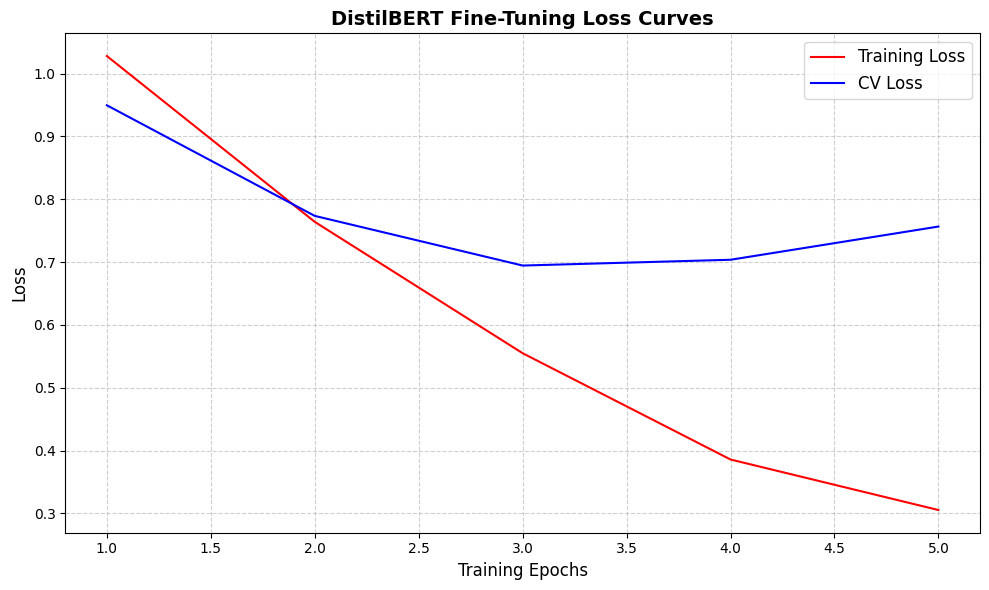

In [66]:
#6. Evaluation
trainer.compute_metrics = compute_metrics
cv_results = trainer.evaluate()

#7. Sanity check!
print('\n' + '='*45)
print('       CROSS-VALIDATION METRIC SCORE       ')
print('='*45)
for metric_name, score in  cv_results.items():
    metric_lower = metric_name.lower()
    if 'loss' in metric_lower or 'accuracy' in metric_lower or 'f1'in metric_lower:
        print(f'{metric_name: <25} : {score: .4f}')

print('='*45)

# 7.1 Training Loss vs. CV Loss
history = trainer.state.log_history

#==== Train Loss Data =====
train_loss = [log["loss"] for log in history if "loss" in log]
train_epochs = [log["epoch"] for log in history if "loss" in log]

#==== CV Loss Data =====
cv_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
cv_epochs = [log["epoch"] for log in history if "eval_loss" in log]

plt.figure(figsize=(10,6))
plt.plot(
    train_epochs, train_loss,
    label = "Training Loss",
    color = 'red',
    linewidth = 1.5
)
plt.plot(
    cv_epochs, cv_loss,
    label = "CV Loss",
    color = 'blue',
    linewidth = 1.5
)
plt.title("DistilBERT Fine-Tuning Loss Curves", fontsize=14, fontweight='bold')
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [67]:
# ==========================================
# 8. Final Holdout Test Set Evaluation
# ==========================================
print("Preparing final out-of-sample Test Set...")

# 1. Convert test series to lists and map integer labels
X_test_list = x_test.to_list()
Y_test_mapped = y_test.str.lower().map(labels).to_numpy()

# 2. Encode using your trained tokenizer
encoded_test = tokenizer(
    X_test_list,
    max_length = 256,
    truncation = True,
    padding = True
)

# 3. Wrap in your Dataset blueprint
test_text = FinanceNewsSentiment(encoded_test, Y_test_mapped)

# 4. Request the trainer to evaluate the brand new dataset
test_results = trainer.evaluate(eval_dataset=test_text)

# ==========================================
# 9. Final Model Verification Report
# ==========================================
print('\n' + '='*45)
print('          FINAL TEST SET METRICS           ')
print('='*45)
for metric_name, score in test_results.items():
    metric_lower = metric_name.lower()
    if 'loss' in metric_lower or 'accuracy' in metric_lower or 'f1' in metric_lower:
        # Reformat key strings for presentation clarity
        clean_name = metric_name.replace("eval_", "test_")
        print(f'{clean_name: <25} : {score: .4f}')
print('='*45)


Preparing final out-of-sample Test Set...

          FINAL TEST SET METRICS           
test_loss                 :  0.7930
test_accuracy             :  0.8182
test_f1                   :  0.7876


Extracting test predictions...

                 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Neutral       0.88      0.58      0.70        12
    Positive       0.82      0.84      0.83        50
    Negative       0.80      0.86      0.83        37

    accuracy                           0.82        99
   macro avg       0.83      0.76      0.79        99
weighted avg       0.82      0.82      0.82        99



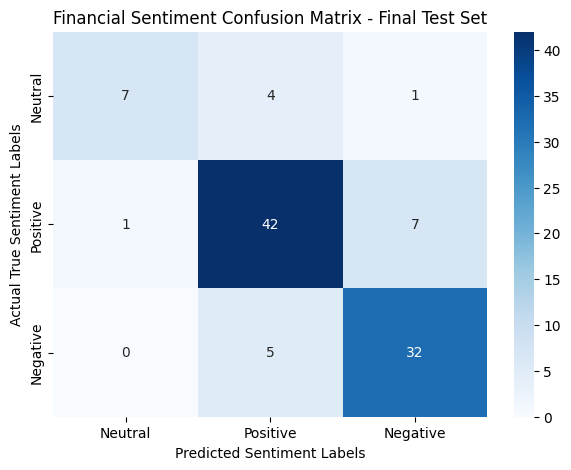

In [68]:
# 1. Generate model predictions for the test dataset
print("Extracting test predictions...")
raw_predictions = trainer.predict(test_text)

# 2. Extract logits and convert them to class IDs
test_logits = raw_predictions.predictions
predicted_classes = np.argmax(test_logits, axis=-1)

# Inverse mapping to turn 0, 1, 2 back into text labels for the chart
class_names = ["Neutral", "Positive", "Negative"]

# 3. Print the text-based precision and recall report
print("\n" + "="*60)
# Use the correct mapped numpy array targets for evaluation comparison
print("                 DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(Y_test_mapped, predicted_classes, target_names=class_names))
print("="*60)

# 4. Generate and plot the Confusion Matrix
cm = confusion_matrix(Y_test_mapped, predicted_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Financial Sentiment Confusion Matrix - Final Test Set")
plt.xlabel("Predicted Sentiment Labels")
plt.ylabel("Actual True Sentiment Labels")
plt.show()


In [ ]:
import os
import shutil
from IPython.display import FileLink

# 1. Define paths
model_directory = "../model/best_finance_sentiment_model"
zip_output_name = "../model/finance_sentiment_model"

# 2. Safety check: Ensure the model files are actually saved on disk first
if not os.path.exists(model_directory):
    print(f"Creating directory and saving model weights to {model_directory}...")
    trainer.save_model(model_directory)
    tokenizer.save_pretrained(model_directory)

# 3. Compress the folder into a .zip archive
print("Compressing model folder... (This may take a moment)")
zip_path = shutil.make_archive(zip_output_name, 'zip', model_directory)

print(f"\nSuccess! Archive created at: {zip_path}")
print("Click the link below to download the model directly to your PC:")

# 4. Generate clickable browser download link
FileLink(f"{zip_output_name}.zip")


Creating directory and saving model weights to ./best_finance_sentiment_model...
Compressing model folder... (This may take a moment)

Success! Archive created at: /model/finance_sentiment_model.zip
Click the link below to download the model directly to your PC:


/model/finance_sentiment_model.zip

In [70]:
pipe = Pipeline ([
    ('tfidf', TfidfVectorizer(max_features= 50000, stop_words = "english")),
    ('lr', LogisticRegression(max_iter= 1000, random_state= 42, class_weight= "balanced"))
])

pipe.fit(X_train_list, Y_train_mapped)

prediction = pipe.predict(X_cv_list)
print("               DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(Y_cv_mapped, prediction))
print("="*60)

# ========== Save The Model ============
joblib.dump(pipe, "tfidf_lr_model.pkl")

               DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.29      0.34      0.32        67
           1       0.73      0.73      0.73       287
           2       0.67      0.63      0.65       207

    accuracy                           0.65       561
   macro avg       0.56      0.57      0.57       561
weighted avg       0.66      0.65      0.65       561



['tfidf_lr_model.pkl']